# Programming exercise 11: Lindblad master equation and Monte Carlo Wave Function Method

Due on Monday, 06.07.2026, 20h

## The problem

Light propagating through an atomic medium is usually scattered and thus absorbed by near-resonant coupling to a transition from the ground ($|g_1\rangle$) to an excited ($|e\rangle$) electronic state. If a second light field ("coupling laser") couples the excited state to a third, long-lived state ($|g_2\rangle$), the medium can again become transparent for the first light field ("probe laser"). This effect, called electromagnetically induced transparency (EIT) - the above description referring to the lambda configuration for obvious reasons - has led to a plethora of applications, see e.g. Rev. Mod. Phys. 77, 633 (2005) [1]. The dynamics of the atomic populations can be simulated using the Lindblad master equation approach, accounting for the coherent driving laser fields and incoherent processes such as spontaneous emission and dephasing, e.g. due to finite laser linewidth. The complex refractive index of the atomic medium is given by $n=\sqrt{1+\chi}\approx 1 + (\chi_R + \chi_I)/2$, where the real and imaginary part of the complex susceptibility $\chi$ account for diffraction and absorption of the probe light respectively. $\chi$ depends on the polarizability of the atomic dipoles in the medium and is thus proportional to expectation value of the operator $|g_1\rangle \langle e|$, i.e. $\rm{tr}[|g_1\rangle \langle e| \rho] = \langle e| \rho |g_1 \rangle = \rho_{eg_1}$. This coherence will thus be the main object of interest.

The interaction with the laser fields is described by the Hamiltonian (in rotating wave approximation, in the basis $\{|g_1\rangle,|g_2\rangle,|e\rangle\}$, following the sign convention used in [1])
$$
H=\left[
\begin{array}{ccc}
0 & 0 & -\Omega_p/2 \\
0 & \Delta_p-\Delta_c & -\Omega_c/2 \\
-\Omega_p/2 & -\Omega_c/2 & \Delta_p
\end{array}
\right]
$$

where $\Omega$'s are Rabi-frequencies and $\Delta$'s are the detunings of the lasers from the respective atomic transitions. $\Delta_p-\Delta_c$ is the "two-photon-detuning" sometimes abbreviated as $\delta_2$.

The dissipative processes we want to consider are the spontaneous emission from $e$ to both stable states $g_1$ and $g_2$ and later also the decay from $g_2$ to $g_1$, which destroys the EIT effect. These are accounted for by the jump operators
$$
\Gamma_{eg_1} = \sqrt{\gamma_p} |g_1\rangle \langle e|, \quad \Gamma_{eg_2} = \sqrt{\gamma_c} |g_2\rangle \langle e|, \quad\Gamma_{g_2g_1} = \sqrt{\gamma_g} |g_1\rangle \langle g_2| .
$$
The resulting master equation reads
$$
\dot\rho = -i[H,\rho] + \mathcal{L}_{\Gamma_{eg_1}} [\rho]+ \mathcal{L}_{\Gamma_{eg_2}} [\rho]+ \mathcal{L}_{\Gamma_{g_2g_1}} [\rho]
$$
with the Lindblad superoperator
$$
\mathcal{L}_{\Gamma_x} [\rho] = \Gamma_x \rho \Gamma_x^\dagger - \frac{1}{2}(\Gamma_x^\dagger\Gamma_x \rho + \rho \Gamma_x^\dagger\Gamma_x)
$$

In [52]:
# load standard libraries

import numpy as np   # standard numerics library
import numpy.linalg as LA
from scipy.integrate import ode

import matplotlib.pyplot as plt   # for making plots

import Comp_Quant_Dynam as cqd 

### Exercise 1: System setup and steady state calculation

Construct the Liouvillian superoperator in matrix form and test your implementation by calculating the steady state for the case of zero two-photon detuning ($\delta_2=0$) and $\gamma_g=0$, which is the pure state ("dark state")
$$
|d\rangle = \frac{\Omega_c |g_1\rangle - \Omega_p |g_2\rangle}{\sqrt{\Omega_p^2 + \Omega_c^2}}.
$$

Detailed instructions (You can of course proceed differently if you want. I am pretty sure the method described in the following is not the most elegant one...):
- Building the Liouvillian in matrix form: We want to formulate the master equation in the standard form of an ordinary differential equation $\dot\rho = \mathcal{L} \rho$ with $\rho$ the density matrix in vector form and $\mathcal{L}$ a matrix summarizing the right-hand side of the master equation. However, the master equation is more conveniently formulated using dot-products between matrices representing operators in Hilbert space. Therefore, it makes sense to write a function that takes the vectorized density matrix as an input (along with the Hamiltonian matrix and the jump operators used in the Lindblad terms), converts it into a matrix using reshape(), calculates the right-hand side of the master equation, and returns the result in vector form by using reshape again. To build the Liouvillian matrix you can loop over all the projectors $|i\rangle\langle j|$ passing them to this function. Those are the unit vectors spanning the space of vectorized density matrices. The outputs will be the columns of the Liouvillian matrix.
- Calculating steady states: The steady state is the unique state for which the right-hand side of the master equation gives zero. Calculating this state numerically is less trivial than it seems. If we just try solving the linear system of equations $\mathcal{L}\rho = 0$ it won't work since $\rho=0$ is always a trivial solution. We need to ensure that the trace of the density matrix is 1. This can be achieved by dropping the first line of the master equation ($\dot\rho_{g_1g_1}=...$) and replacing $\rho_{g_1g_1} = 1-\rho_{g_2g_2}-\rho_{ee}$ everywhere. The resulting inhomogeneous system of 8 equations can be solved using np.linalg.solve(). $\rho_{g_1g_1}$ can be prepended to the solution by using the trace condition again. There are many other ways to calculate steady states, see for example the qutip documentation (http://qutip.org/docs/4.0.2/guide/guide-steady.html). You can of course also use qutip routines to check your results.

In [11]:
# Parameters
Omega_p = 1.0
Omega_c = 5.0

Delta_p = 0.0
Delta_c = 0.0

gamma_p = 1.0
gamma_c = 1.0
gamma_g = 0.0

H = np.array([
    [0, 0, -Omega_p/2],
    [0, Delta_p-Delta_c, -Omega_c/2],
    [-Omega_p/2, -Omega_c/2, Delta_p]
], dtype=complex)

g1 = np.array([1,0,0], dtype=complex)
g2 = np.array([0,1,0], dtype=complex)
e  = np.array([0,0,1], dtype=complex)

#jump operators
def outer(a,b):
    return np.outer(a,b.conj())

J1 = np.sqrt(gamma_p) * outer(g1,e)
J2 = np.sqrt(gamma_c) * outer(g2,e)
J3 = np.sqrt(gamma_g) * outer(g1,g2)

jump_ops = [J1,J2,J3]

# Lindblad terms (superoperator)
def lindblad(rho, J):
    return ( J @ rho @ J.conj().T - 0.5 * (J.conj().T @ J @ rho + rho @ J.conj().T @ J))

#rhs of Master equation
def master_rhs(rho_vec, H, jump_ops):
    rho = rho_vec.reshape((3,3))   #rho as (9) vector with matrix entries in order (rho_00,rho_01,....)^T
    drho = -1j*(H@rho - rho@H)     # commutator -i*[rho,H]
    for J in jump_ops:
        drho += lindblad(rho,J)
    return drho.reshape(9)         # drho vector with all changed matrix entries

# Louville operator (9,9) --> coloums given by solving master eq with basis vectors
L = np.zeros((9,9), dtype=complex)

for i in range(9):

    basis = np.zeros(9, dtype=complex)
    basis[i] = 1.0

    L[:,i] = master_rhs(basis, H, jump_ops)

# --> drho = L @ rho_vec

# steady states: drho = L@rho_vec =! 0 --> but trace preserving(tr(drho)=1) --> set rho_11 = 1-rho_22-rho_33 -->solve A@rho_vec = b for unknown rho_vec
# instead of 9 equations ( L_11 * rho_11 + L_12 *rho_12 + .... = 0 ....) we get 8 with conditions but with condition of trace = 1 = rho_11 +rho_22+rho_33

A = L[1:,:].copy()                 #(8x9 L matrix) row with rho_11 deleted
b = np.zeros(8,dtype=complex)
#save first coulum (info about rho_11)
col0 = A[:,0].copy()

#delete rho_11 coloum in A
A = A[:,1:]   #8x8 matrix

A[:, 3] -= col0      # rho22
A[:, 7] -= col0      # rho33

b = -col0

#solving Linear equation System
x = np.linalg.solve(A, b)
rho12, rho13, rho21, rho22, rho23, rho31, rho32, rho33 = x

rho11 = 1 - rho22 - rho33

#building final rho
rho = np.array([
    [rho11, rho12, rho13],
    [rho21, rho22, rho23],
    [rho31, rho32, rho33]
], dtype=complex)

#testing dark state
d = np.array([Omega_c,-Omega_p,0], dtype=complex)
d /= np.linalg.norm(d)
rho_dark = np.outer(d,d.conj())

print("calculated steady state: ",rho)
print("Theoretical steady state: ",rho_dark)

calculated steady state:  [[ 0.96153846+0.j -0.19230769+0.j  0.        +0.j]
 [-0.19230769+0.j  0.03846154-0.j -0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j]]
Theoretical steady state:  [[ 0.96153846+0.j -0.19230769-0.j  0.        +0.j]
 [-0.19230769+0.j  0.03846154+0.j  0.        +0.j]
 [ 0.        +0.j  0.        -0.j  0.        +0.j]]


### Exercise 2: Physical properties of the steady state

- Scan the probe detuning $\Delta_p$ at resonant coupling beam ($\Delta_c=0$). Plot imaginary and real part of the steady-state value of $\rho_{eg_1}$ as a function of $\Delta_p$. Start with parameters $\Omega_p=\Omega_c=\gamma_p=1$ and all other parameters zero. You should see the charactersitic EIT dip in the absorption (see Fig. 1 in [1]). Then change the coupling Rabi frequency to a larger value to see what happens (Fig. 7 in [1]). Can you interpret the result in the dressed-state picture? Also change $\gamma_p$ and $\gamma_c$ and describe your observations. In principle, $\gamma_p$ can be set to 1, defining the energy scale.
- Now add a spontaneous decay from $g_2$ to $g_1$. Make the same plots again (imaginary part of the steady state $\rho_{eg_1}$, i.e. absorption, as a function of $\Delta_p$) for a fixed value of $\Omega_c=\gamma_p=1$ and various values of $\gamma_{g}$. What do you observe? Compare to Fig. 10 in [1].

Describe and interpret your results.

<>:75: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:75: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\Bened\AppData\Local\Temp\ipykernel_14440\4053421189.py:75: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  plt.title(f"Real and imaginary part of rho_eg for Rabi frequency $\Omega_c$ ={Omega_c}")


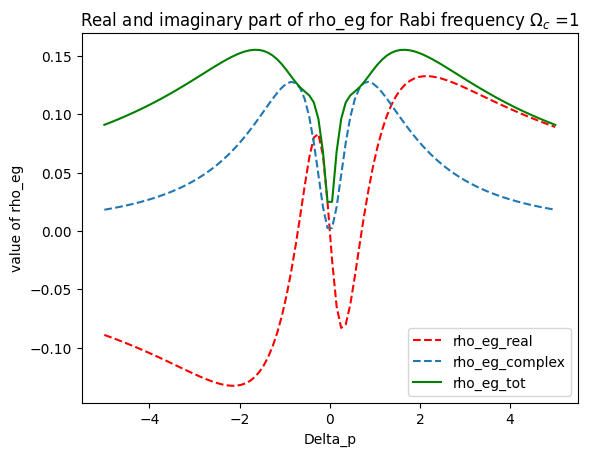

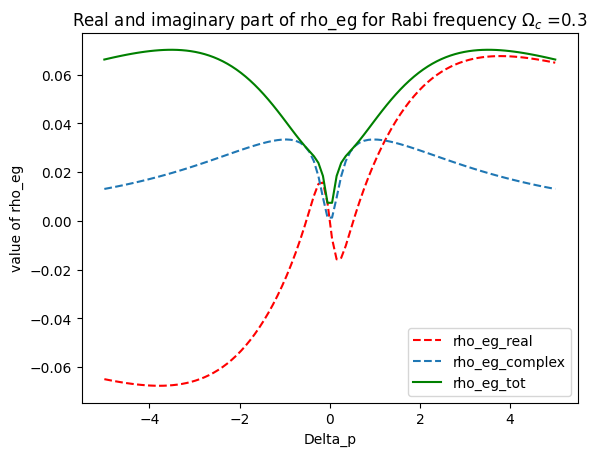

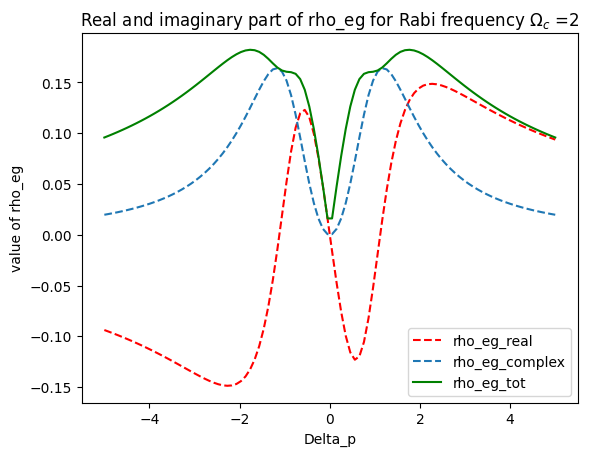

In [47]:
Delta_p_vals = np.linspace(-5,5,100)
Delta_c = 0.0

Omega_c_value = [1,0.3,2]
Omega_p = 1

gamma_p = 1
gamma_g = 0   # No g2 --> g2 decay
gamma_c = [0,1,1]

for k,Omega_c in enumerate(Omega_c_value):
    rho_eg_real = []
    rho_eg_complex = []
    rho_eg_tot = []
    for i, Delta_p in enumerate(Delta_p_vals):
        H = np.array([[0, 0, -Omega_p/2],[0, Delta_p-Delta_c, -Omega_c/2],[-Omega_p/2, -Omega_c/2, Delta_p]], dtype=complex)

        g1 = np.array([1,0,0], dtype=complex)
        g2 = np.array([0,1,0], dtype=complex)
        e  = np.array([0,0,1], dtype=complex)

        J1 = np.sqrt(gamma_p) * outer(g1,e)
        J2 = np.sqrt(gamma_c) * outer(g2,e)
        J3 = np.sqrt(gamma_g) * outer(g1,g2)

        jump_ops = [J1,J2,J3]

        def master_rhs(rho_vec, H, jump_ops):
            rho = rho_vec.reshape((3,3))   #rho as (9) vector with matrix entries in order (rho_00,rho_01,....)^T
            drho = -1j*(H@rho - rho@H)     # commutator -i*[rho,H]
            for J in jump_ops:
                drho += lindblad(rho,J)
            return drho.reshape(9)         # drho vector with all changed matrix entries

        L = np.zeros((9,9), dtype=complex)

        for j in range(9):

            basis = np.zeros(9, dtype=complex)
            basis[j] = 1.0

            L[:,j] = master_rhs(basis, H, jump_ops)

        A = L[1:,:].copy()                 #(8x9 L matrix) row with rho_11 deleted
        b = np.zeros(8,dtype=complex)
        col0 = A[:,0].copy()

        A = A[:,1:]   #8x8 matrix

        A[:, 3] -= col0      # rho22
        A[:, 7] -= col0      # rho33

        b = -col0

        x = np.linalg.solve(A, b)
        rho12, rho13, rho21, rho22, rho23, rho31, rho32, rho33 = x

        rho11 = 1 - rho22 - rho33

        #building final rho
        rho = np.array([
            [rho11, rho12, rho13],
            [rho21, rho22, rho23],
            [rho31, rho32, rho33]
        ], dtype=complex)

        rho_eg_real.append(np.real(rho[2,0]))
        rho_eg_complex.append(np.imag(rho[2,0]))
        rho_eg_tot.append(np.absolute(rho[2,0]))

    plt.plot(Delta_p_vals, rho_eg_real,label="rho_eg_real",color="r",linestyle="--")
    plt.plot(Delta_p_vals, rho_eg_complex,label="rho_eg_complex",linestyle="--")
    plt.plot(Delta_p_vals, rho_eg_tot, label="rho_eg_tot",color="g")
    plt.legend()
    plt.title(f"Real and imaginary part of rho_eg for Rabi frequency $\Omega_c$ ={Omega_c}")
    plt.xlabel("Delta_p")
    plt.ylabel("value of rho_eg")
    plt.show()


<>:76: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:76: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\Bened\AppData\Local\Temp\ipykernel_14440\3678681043.py:76: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.title(f"Real and imaginary part of rho_eg for Rabi frequency $\gamma_g$ ={gamma_g}")


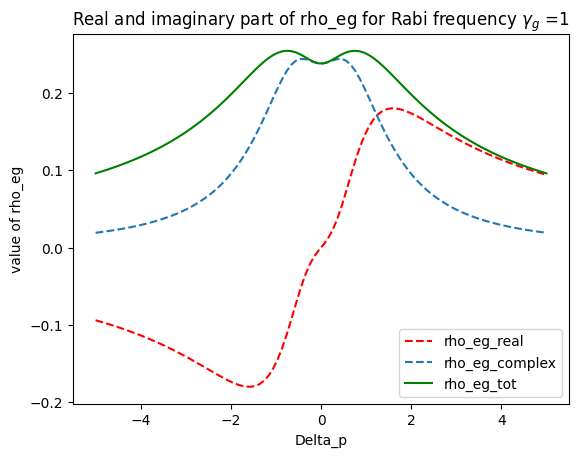

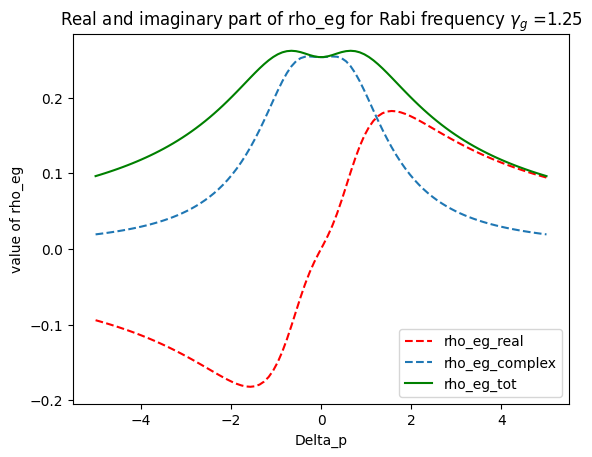

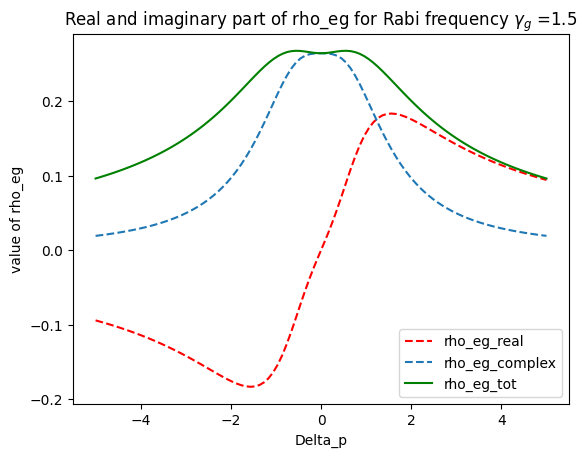

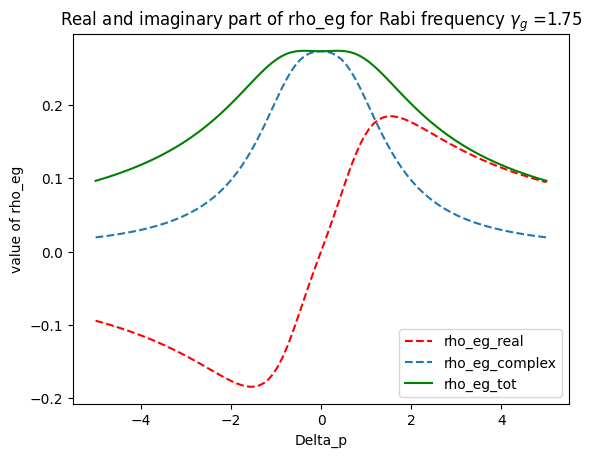

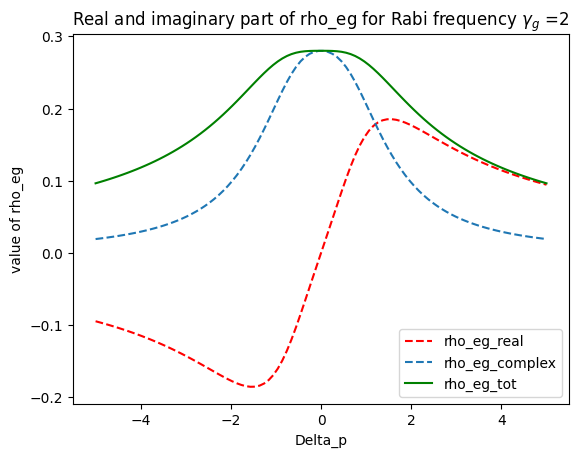

In [ ]:
#same as before but with g2--> g1 decay --> gamma_g NOT 0
Delta_p_vals = np.linspace(-5,5,100)
Delta_c = 0.0

Omega_c = 1
Omega_p = 1

gamma_p = 1
gamma_g_values = [1,1.25,1.5,1.75,2]
gamma_c = 1

for k,gamma_g in enumerate(gamma_g_values):
    rho_eg_real = []
    rho_eg_complex = []
    rho_eg_tot = []
    for i, Delta_p in enumerate(Delta_p_vals):
        H = np.array([[0, 0, -Omega_p/2],
                      [0, Delta_p-Delta_c, -Omega_c/2],
                      [-Omega_p/2, -Omega_c/2, Delta_p]], dtype=complex)

        g1 = np.array([1,0,0], dtype=complex)
        g2 = np.array([0,1,0], dtype=complex)
        e  = np.array([0,0,1], dtype=complex)

        J1 = np.sqrt(gamma_p) * outer(g1,e)
        J2 = np.sqrt(gamma_c) * outer(g2,e)
        J3 = np.sqrt(gamma_g) * outer(g1,g2)

        jump_ops = [J1,J2,J3]

        def master_rhs(rho_vec, H, jump_ops):
            rho = rho_vec.reshape((3,3))   #rho as (9) vector with matrix entries in order (rho_00,rho_01,....)^T
            drho = -1j*(H@rho - rho@H)     # commutator -i*[rho,H]
            for J in jump_ops:
                drho += lindblad(rho,J)
            return drho.reshape(9)         # drho vector with all changed matrix entries

        L = np.zeros((9,9), dtype=complex)

        for j in range(9):

            basis = np.zeros(9, dtype=complex)
            basis[j] = 1.0

            L[:,j] = master_rhs(basis, H, jump_ops)

        A = L[1:,:].copy()                 #(8x9 L matrix) row with rho_11 deleted
        b = np.zeros(8,dtype=complex)
        col0 = A[:,0].copy()

        A = A[:,1:]   #8x8 matrix

        A[:, 3] -= col0      # rho22
        A[:, 7] -= col0      # rho33

        b = -col0

        x = np.linalg.solve(A, b)
        rho12, rho13, rho21, rho22, rho23, rho31, rho32, rho33 = x

        rho11 = 1 - rho22 - rho33

        #building final rho
        rho = np.array([
            [rho11, rho12, rho13],
            [rho21, rho22, rho23],
            [rho31, rho32, rho33]
        ], dtype=complex)

        rho_eg_real.append(np.real(rho[2,0]))
        rho_eg_complex.append(np.imag(rho[2,0]))
        rho_eg_tot.append(np.absolute(rho[2,0]))

    plt.plot(Delta_p_vals, rho_eg_real,label="rho_eg_real",color="r",linestyle="--")
    plt.plot(Delta_p_vals, rho_eg_complex,label="rho_eg_complex",linestyle="--")
    plt.plot(Delta_p_vals, rho_eg_tot, label="rho_eg_tot",color="g")
    plt.legend()
    plt.title(f"Real and imaginary part of rho_eg for Rabi frequency $\gamma_g$ ={gamma_g}")
    plt.xlabel("Delta_p")
    plt.ylabel("value of rho_eg")
    plt.show()

### Exercise 3: Dissipative dynamics

Solve the time dependent master equation with initial state $\rho_0 = |g_1\rangle \langle g_1|$. You can use a scipy integrator, for example the one used in exercise sheet 5. Plot the populations of the levels and the real and imaginary part of $\rho_{eg_1}$ as a function of time. Good example parameters are $\Omega_p = 1, \Omega_c = \gamma_p = 2$ and the others zero, integrating to $t=10$. Check qualitatively how the time for approaching the steady state depends on the parameters, especially on $\Omega_c$ and $\gamma_p$.

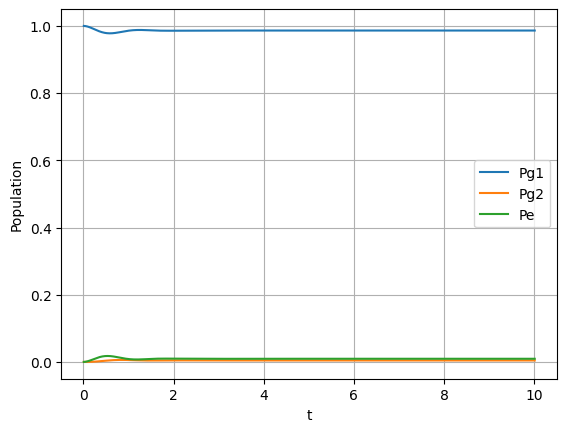

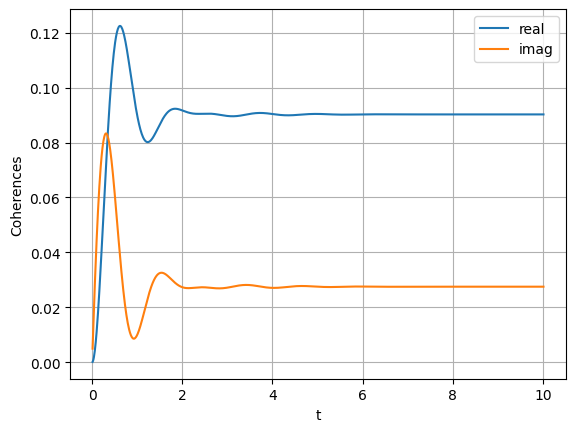

In [56]:
Delta_p_vals = 1
Delta_c = 2

Omega_c = 1
Omega_p = 1

gamma_p = 2
gamma_g_values = 1 #[1,1.25,1.5,1.75,2]
gamma_c = 1
g1 = np.array([1,0,0], dtype=complex)
g2 = np.array([0,1,0], dtype=complex)
e  = np.array([0,0,1], dtype=complex)
ini = outer(g1,g1)
rho_0 = ini.reshape(9)

J1 = np.sqrt(gamma_p) * outer(g1,e)
J2 = np.sqrt(gamma_c) * outer(g2,e)
J3 = np.sqrt(gamma_g) * outer(g1,g2)

jump_ops = [J1,J2,J3]

L = np.zeros((9,9), dtype=complex)

for j in range(9):

    basis = np.zeros(9, dtype=complex)
    basis[j] = 1.0

    L[:,j] = master_rhs(basis, H, jump_ops)

A = L[1:,:].copy()                 #(8x9 L matrix) row with rho_11 deleted
b = np.zeros(8,dtype=complex)
col0 = A[:,0].copy()

A = A[:,1:]   #8x8 matrix

A[:, 3] -= col0      # rho22
A[:, 7] -= col0      # rho33

b = -col0

x = np.linalg.solve(A, b)
rho12, rho13, rho21, rho22, rho23, rho31, rho32, rho33 = x

rho11 = 1 - rho22 - rho33

#building final rho
rho = np.array([
    [rho11, rho12, rho13],
    [rho21, rho22, rho23],
    [rho31, rho32, rho33]
], dtype=complex)

#solve Lindblad eq instead of schrödinger eq
def rhs(t, rho_vec, H, jump_ops):
    return master_rhs(rho_vec, H, jump_ops)

r = ode(rhs) 

r.set_integrator(       #integrator
    'zvode',
    method='adams',
    atol=1e-12,
    rtol=1e-10
)

r.set_initial_value(rho_0,0)

r.set_f_params(H,jump_ops)

#integration
dt = 0.01
tmax = 10

times = []
states = []

while r.successful() and r.t < tmax:

    r.integrate(r.t + dt)

    times.append(r.t)
    states.append(r.y.copy())  #states[i] 9dim vec
rho = states[i].reshape((3,3))


Pg1 = []
Pg2 = []
Pe  = []

Re_coh = []
Im_coh = []

for state in states:

    rho = state.reshape((3,3))
    
    #population is rho_g1g1 , rho_g2g2, rho_ee
    Pg1.append(rho[0,0].real)
    Pg2.append(rho[1,1].real)
    Pe.append(rho[2,2].real)

    #coherences
    Re_coh.append(rho[2,0].real)
    Im_coh.append(rho[2,0].imag)

#Plot population
plt.plot(times,Pg1,label="Pg1")
plt.plot(times,Pg2,label="Pg2")
plt.plot(times,Pe,label="Pe")
plt.xlabel("t")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

#Plot coherences
plt.plot(times,Re_coh,label="real")
plt.plot(times,Im_coh,label="imag")
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("Coherences")
plt.show()

### Exercise 4: Monte Carlo wave function method

Now we want to solve the dynamics using the Monte Carlo wave function technique. For such a small system (3-dimensional Hilbert space) the method will not be more efficient than directly integrating the master equation. However, when it comes to many-body spin systems, for example, the reduction from a $4^N$ to a $2^N$ dimensional problem at the expense of doing stochastic sampling, can be extremely useful.

First, calculate a single jump trajectory by implementing the algorithm discussed in the lecture (see also Rev. Mod. Phys. 70, 101-144, 1998). Initially the system is in state $|g_1\rangle$.

Try out the following cases: 
- "Standard EIT" case: $\Omega_p=1, \Omega_c=2, \gamma_p=2$ and all other parameters zero. Calculate the evolution up to $t=10$, plotting the populations of the three states. There should not be many jumps in this case. At long times any single trajectory should go to the correct dark state, which you can check using the analytical solution for the dark state. Even if you don't allow any jumps by setting the jump probability to zero, such that you simply propagate with the non-hermitian Hamiltonian and renormalize after each step, you already converge to the correct steady state. (Why?)
- "On-off" case. When $\Omega_p$ and $\Gamma_p$ are much larger than $\Omega_c$ and $\Gamma_c$, we have a situation that is similar to the Dehmelt setup (Phys. Rev. Lett. 57, 1699) with the difference that we have a $\Lambda$-scheme instead of a V-scheme. For the lambda scheme we always have EIT, i.e. the system will end up in the dark state after some time. However, if we add a small decay $\gamma_g$ there is no exact dark state any more and we can observe a similar behavior to the "telegraph noise" reported in Phys. Rev. Lett. 57, 1699, where the atom alternates between a fluorescing state and a dark state. Try the parameters $\Omega_p=1, \Omega_c=0.1, \gamma_p=1, \gamma_c=0.1, \gamma_g=0.01$ and integrate to a long time ($t=1000$).
- Optional: In the V-scheme the difference is that the decay is from the $g$-states to the $e$-state. In this case there is no true dark state. On the other hand, the resulting dynamics we get from the quantum jump simulation is not quite what one expects from the experiment with a single ion. Why is this? What are we missing? If we instead make a ladder scheme with a decay from $g_1$ to $e$ and from $e$ to $g_2$, the telegraph noise behavior is recovered. Try this case with $\Omega_p=1, \Omega_c=0.1, \bar{\gamma}_p=1, \gamma_c=0.1$, where the overbar indicates that the decay goes into the opposite direction compared to the EIT case. Again integrate to a long time.

Secondly, implement the actual Monte Carlo wave function method: Average the observables over many jump trajectories.

To start, try the parameters of the "Standard EIT" case. For 100 jump trajectories and a time step of 0.1 you should already get reasonable results. Compare the result for the populations and the imaginary part of $\rho_{eg_1}$ (absorption) to the direct integration of the master equation from Exercise 3 above.

Also plot ~50 single trajectories (e.g. plotting $\rho_{g_1g_1}$) into one plot to see what the averaging does.